# Real Data 02 - Basket Option Pricing

This notebook takes the real-data calibration from notebook 01 and prices a **hypothetical** semiconductor basket call under:

1. a constant-correlation multi-asset Black-Scholes model;
2. a regime-switching correlation model calibrated from the historical calm/stress labeling.

## Basket definition

Because these stocks have very different nominal share prices, we do **not** use raw equal weights on levels. Instead, we build an equal-dollar basket:

$$
B(t) = \sum_{i=1}^N \alpha_i S_i(t),
\qquad
\alpha_i = \frac{100/N}{S_i(0)}.
$$

This makes each stock contribute the same initial dollar amount and sets

$$
B(0)=100.
$$

We then price an at-the-money basket call with payoff

$$
g(S_T) = (B(T)-K)^+,
\qquad
K = B(0)=100.
$$

All pricing is under a risk-neutral Monte Carlo model with a simple illustrative rate assumption and zero dividends.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root()
REAL_DIR = PROJECT_ROOT / "real_simulation"
DATA_DIR = REAL_DIR / "data"

In [2]:
prices = pd.read_csv(DATA_DIR / "semiconductor_prices.csv", parse_dates=["Date"]).set_index("Date")
vols = pd.read_csv(DATA_DIR / "annualized_volatility_estimates.csv").set_index("ticker")
constant_corr = pd.read_csv(DATA_DIR / "constant_correlation_matrix.csv", index_col=0)
calm_corr = pd.read_csv(DATA_DIR / "calm_correlation_matrix.csv", index_col=0)
stress_corr = pd.read_csv(DATA_DIR / "stress_correlation_matrix.csv", index_col=0)
transition_matrix = pd.read_csv(DATA_DIR / "regime_transition_matrix.csv").rename(columns={"Unnamed: 0": "state"}).set_index("state")
regime_labels = pd.read_csv(DATA_DIR / "regime_labels.csv", parse_dates=["Date"]).set_index("Date")

tickers = list(constant_corr.columns)
latest_spot = prices.loc[prices.index.max(), tickers].to_numpy(dtype=float)
sigma = vols.loc[tickers, "annualized_volatility"].to_numpy(dtype=float)

basket_notional = 100.0
allocation_weights = np.full(len(tickers), 1.0 / len(tickers))
share_weights = basket_notional * allocation_weights / latest_spot
basket_0 = float(share_weights @ latest_spot)
strike = basket_0

rate = 0.04
div_yield = np.zeros(len(tickers))
maturity = 1.0
steps_per_year = 12
n_paths_main = 20000
convergence_grid = [1000, 2500, 5000, 10000, 20000]

p01_daily = float(transition_matrix.loc["calm", "to_stress"])
p10_daily = float(transition_matrix.loc["stress", "to_calm"])
daily_transition = np.array(
    [
        [1.0 - p01_daily, p01_daily],
        [p10_daily, 1.0 - p10_daily],
    ]
)
transition_step = np.linalg.matrix_power(daily_transition, 21)

current_regime = int(regime_labels["regime"].iloc[-1])
current_regime_label = "stress" if current_regime == 1 else "calm"

basket_definition = pd.DataFrame(
    {
        "ticker": tickers,
        "spot": latest_spot,
        "annualized_volatility": sigma,
        "allocation_weight": allocation_weights,
        "share_weight": share_weights,
        "initial_dollar_contribution": share_weights * latest_spot,
    }
)

pricing_config = pd.Series(
    {
        "valuation_date": prices.index.max().date().isoformat(),
        "basket_notional": basket_notional,
        "basket_initial_value": basket_0,
        "strike": strike,
        "risk_free_rate": rate,
        "maturity_years": maturity,
        "pricing_paths": n_paths_main,
        "regime_steps_per_year": steps_per_year,
        "start_regime": current_regime_label,
        "p01_daily": p01_daily,
        "p10_daily": p10_daily,
    },
    name="value",
)

display(Markdown("## Basket definition"))
display(basket_definition)

display(Markdown("## Pricing configuration"))
display(pricing_config.to_frame())

## Basket definition

,ticker,spot,annualized_volatility,allocation_weight,share_weight,initial_dollar_contribution
0,NVDA,180.2500,0.5093,0.2000,0.1110,20.0000
1,AVGO,322.1600,0.4126,0.2000,0.0621,20.0000
2,MU,426.1300,0.4997,0.2000,0.0469,20.0000
3,AMAT,341.5300,0.4504,0.2000,0.0586,20.0000
4,LRCX,212.2000,0.4685,0.2000,0.0943,20.0000


## Pricing configuration

,value
valuation_date,2026-03-13
basket_notional,100.0000
basket_initial_value,100.0000
strike,100.0000
risk_free_rate,0.0400
maturity_years,1.0000
pricing_paths,20000
regime_steps_per_year,12
start_regime,calm
p01_daily,0.0173


In [3]:
def basket_call_payoff(terminal_prices, share_weights, strike):
    basket_terminal = terminal_prices @ share_weights
    return np.maximum(basket_terminal - strike, 0.0), basket_terminal


def monte_carlo_summary(discounted_payoffs, model_name, n_paths, extra=None):
    price = float(discounted_payoffs.mean())
    payoff_std = float(discounted_payoffs.std(ddof=1))
    std_error = payoff_std / np.sqrt(n_paths)
    summary = {
        "model": model_name,
        "price": price,
        "std_error": std_error,
        "ci_low": price - 1.96 * std_error,
        "ci_high": price + 1.96 * std_error,
        "discounted_payoff_std": payoff_std,
        "n_paths": int(n_paths),
    }
    if extra:
        summary.update(extra)
    return summary


def simulate_constant_model(spot, sigma, corr, share_weights, strike, rate, div_yield, maturity, n_paths, seed):
    rng = np.random.default_rng(seed)
    chol = np.linalg.cholesky(corr)
    shocks = rng.standard_normal((n_paths, spot.size)) @ chol.T
    drift = (rate - div_yield - 0.5 * sigma ** 2) * maturity
    diffusion = sigma * np.sqrt(maturity) * shocks
    terminal_prices = spot * np.exp(drift + diffusion)
    payoff, basket_terminal = basket_call_payoff(terminal_prices, share_weights, strike)
    discounted_payoff = np.exp(-rate * maturity) * payoff
    return discounted_payoff, basket_terminal


def simulate_regime_switching_model(
    spot,
    sigma,
    calm_corr,
    stress_corr,
    share_weights,
    strike,
    rate,
    div_yield,
    maturity,
    steps_per_year,
    transition_step,
    start_regime,
    n_paths,
    seed,
):
    rng = np.random.default_rng(seed)
    n_assets = spot.size
    n_steps = steps_per_year
    dt = maturity / n_steps
    chol_by_regime = {
        0: np.linalg.cholesky(calm_corr),
        1: np.linalg.cholesky(stress_corr),
    }

    paths = np.empty((n_paths, n_assets), dtype=float)
    paths[:] = spot
    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)
    regime_history = np.empty((n_paths, n_steps), dtype=np.int8)

    drift = (rate - div_yield - 0.5 * sigma ** 2) * dt
    diffusion_scale = sigma * np.sqrt(dt)

    for step in range(n_steps):
        regime_history[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, n_assets))
        correlated_draws = np.empty_like(base_draws)
        for regime_value, chol in chol_by_regime.items():
            mask = current_regimes == regime_value
            if np.any(mask):
                correlated_draws[mask] = base_draws[mask] @ chol.T
        paths *= np.exp(drift + diffusion_scale * correlated_draws)

        if step < n_steps - 1:
            stress_prob = transition_step[current_regimes, 1]
            current_regimes = (rng.random(n_paths) < stress_prob).astype(np.int8)

    payoff, basket_terminal = basket_call_payoff(paths, share_weights, strike)
    discounted_payoff = np.exp(-rate * maturity) * payoff
    return discounted_payoff, basket_terminal, regime_history.mean(axis=1)

In [4]:
main_seed_offset = len(convergence_grid) - 1

constant_discounted, constant_basket_terminal = simulate_constant_model(
    spot=latest_spot,
    sigma=sigma,
    corr=constant_corr.to_numpy(),
    share_weights=share_weights,
    strike=strike,
    rate=rate,
    div_yield=div_yield,
    maturity=maturity,
    n_paths=n_paths_main,
    seed=9000 + main_seed_offset,
)

regime_discounted, regime_basket_terminal, regime_stress_fraction = simulate_regime_switching_model(
    spot=latest_spot,
    sigma=sigma,
    calm_corr=calm_corr.to_numpy(),
    stress_corr=stress_corr.to_numpy(),
    share_weights=share_weights,
    strike=strike,
    rate=rate,
    div_yield=div_yield,
    maturity=maturity,
    steps_per_year=steps_per_year,
    transition_step=transition_step,
    start_regime=current_regime,
    n_paths=n_paths_main,
    seed=12000 + main_seed_offset,
)

pricing_summary = pd.DataFrame(
    [
        monte_carlo_summary(
            constant_discounted,
            "Constant correlation",
            n_paths_main,
            extra={"avg_terminal_basket": float(constant_basket_terminal.mean()), "avg_stress_fraction": np.nan},
        ),
        monte_carlo_summary(
            regime_discounted,
            "Regime switching",
            n_paths_main,
            extra={"avg_terminal_basket": float(regime_basket_terminal.mean()), "avg_stress_fraction": float(regime_stress_fraction.mean())},
        ),
    ]
)
pricing_summary["price_difference_vs_constant"] = pricing_summary["price"] - pricing_summary.loc[
    pricing_summary["model"] == "Constant correlation", "price"
].iloc[0]

convergence_rows = []
for idx, n_paths in enumerate(convergence_grid):
    constant_discounted_n, _ = simulate_constant_model(
        spot=latest_spot,
        sigma=sigma,
        corr=constant_corr.to_numpy(),
        share_weights=share_weights,
        strike=strike,
        rate=rate,
        div_yield=div_yield,
        maturity=maturity,
        n_paths=n_paths,
        seed=9000 + idx,
    )
    convergence_rows.append(monte_carlo_summary(constant_discounted_n, "Constant correlation", n_paths))

    regime_discounted_n, _, regime_fraction_n = simulate_regime_switching_model(
        spot=latest_spot,
        sigma=sigma,
        calm_corr=calm_corr.to_numpy(),
        stress_corr=stress_corr.to_numpy(),
        share_weights=share_weights,
        strike=strike,
        rate=rate,
        div_yield=div_yield,
        maturity=maturity,
        steps_per_year=steps_per_year,
        transition_step=transition_step,
        start_regime=current_regime,
        n_paths=n_paths,
        seed=12000 + idx,
    )
    convergence_rows.append(
        monte_carlo_summary(
            regime_discounted_n,
            "Regime switching",
            n_paths,
            extra={"avg_stress_fraction": float(regime_fraction_n.mean())},
        )
    )

convergence = pd.DataFrame(convergence_rows)

display(Markdown("## Real-data pricing summary"))
display(pricing_summary)

display(Markdown("## Convergence table"))
display(convergence)

## Real-data pricing summary

,model,price,std_error,ci_low,ci_high,discounted_payoff_std,n_paths,avg_terminal_basket,avg_stress_fraction,price_difference_vs_constant
0,Constant correlation,17.9875,0.2271,17.5423,18.4327,32.1234,20000,104.1966,NaN,0.0000
1,Regime switching,17.3467,0.2207,16.9141,17.7794,31.2168,20000,104.0852,0.1367,-0.6408


## Convergence table

,model,price,std_error,ci_low,ci_high,discounted_payoff_std,n_paths,avg_stress_fraction
0,Constant correlation,17.2070,0.9136,15.4162,18.9977,28.8919,1000,NaN
1,Regime switching,17.6511,0.9906,15.7096,19.5926,31.3244,1000,0.1368
2,Constant correlation,17.3937,0.6086,16.2008,18.5866,30.4314,2500,NaN
3,Regime switching,17.0325,0.6116,15.8337,18.2313,30.5811,2500,0.1387
4,Constant correlation,17.3564,0.4457,16.4828,18.2300,31.5170,5000,NaN
5,Regime switching,18.4090,0.4522,17.5228,19.2953,31.9746,5000,0.1372
6,Constant correlation,18.1568,0.3187,17.5322,18.7814,31.8686,10000,NaN
7,Regime switching,17.5451,0.3068,16.9439,18.1464,30.6781,10000,0.1351
8,Constant correlation,17.9875,0.2271,17.5423,18.4327,32.1234,20000,NaN
9,Regime switching,17.3467,0.2207,16.9141,17.7794,31.2168,20000,0.1367


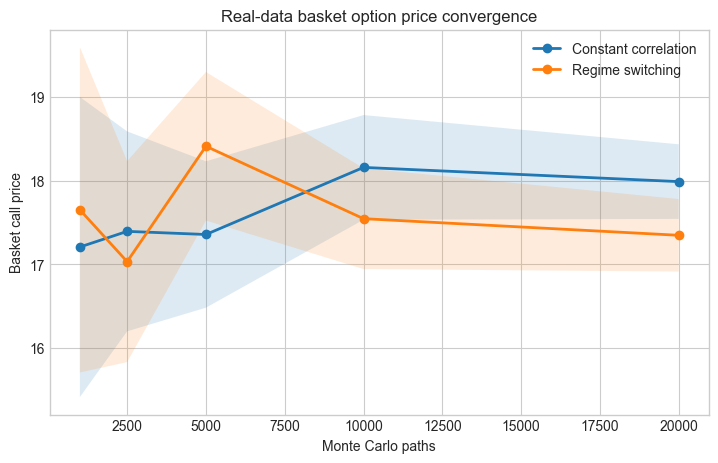

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for model, frame in convergence.groupby("model"):
    frame = frame.sort_values("n_paths")
    ax.plot(frame["n_paths"], frame["price"], marker="o", linewidth=2, label=model)
    ax.fill_between(frame["n_paths"], frame["ci_low"], frame["ci_high"], alpha=0.15)

ax.set_title("Real-data basket option price convergence")
ax.set_xlabel("Monte Carlo paths")
ax.set_ylabel("Basket call price")
ax.legend()
plt.show()

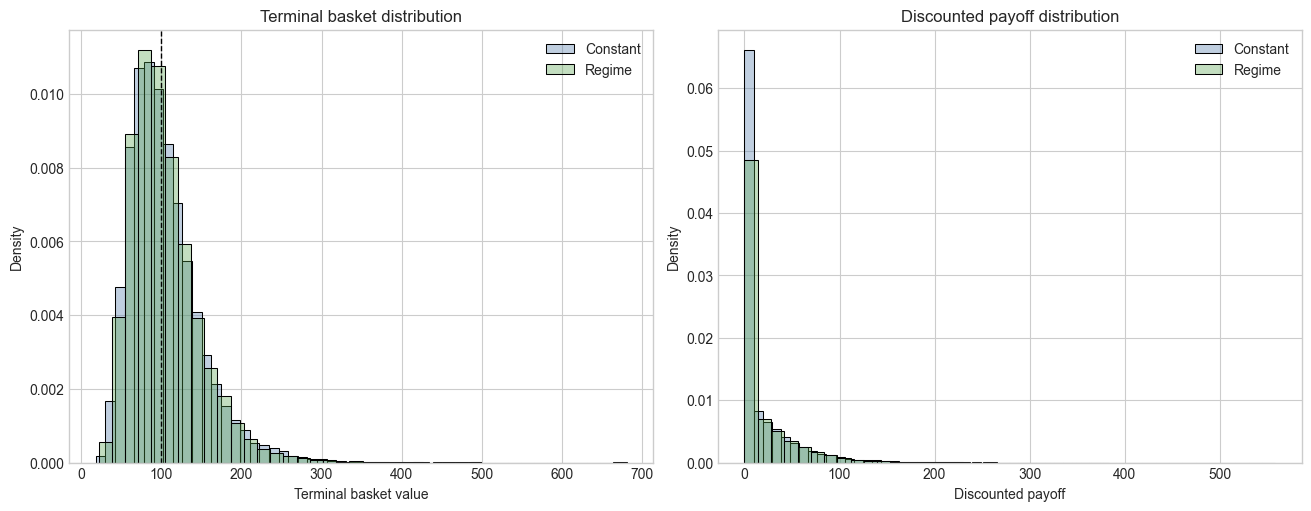

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.histplot(constant_basket_terminal, bins=40, stat="density", alpha=0.35, color="#4c78a8", label="Constant", ax=axes[0])
sns.histplot(regime_basket_terminal, bins=40, stat="density", alpha=0.35, color="#54a24b", label="Regime", ax=axes[0])
axes[0].axvline(strike, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("Terminal basket distribution")
axes[0].set_xlabel("Terminal basket value")
axes[0].legend()

sns.histplot(constant_discounted, bins=40, stat="density", alpha=0.35, color="#4c78a8", label="Constant", ax=axes[1])
sns.histplot(regime_discounted, bins=40, stat="density", alpha=0.35, color="#54a24b", label="Regime", ax=axes[1])
axes[1].set_title("Discounted payoff distribution")
axes[1].set_xlabel("Discounted payoff")
axes[1].legend()
plt.show()

In [7]:
basket_definition.to_csv(DATA_DIR / "real_basket_definition.csv", index=False)
pricing_config.to_csv(DATA_DIR / "real_basket_pricing_config.csv")
pricing_summary.to_csv(DATA_DIR / "real_basket_option_pricing_summary.csv", index=False)
convergence.to_csv(DATA_DIR / "real_basket_option_pricing_convergence.csv", index=False)

print(f"Saved basket definition to {DATA_DIR / 'real_basket_definition.csv'}")
print(f"Saved pricing config to {DATA_DIR / 'real_basket_pricing_config.csv'}")
print(f"Saved pricing summary to {DATA_DIR / 'real_basket_option_pricing_summary.csv'}")
print(f"Saved convergence table to {DATA_DIR / 'real_basket_option_pricing_convergence.csv'}")

Saved basket definition to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_definition.csv
Saved pricing config to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_pricing_config.csv
Saved pricing summary to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_option_pricing_summary.csv
Saved convergence table to /Users/hamzaahmed/Multi-Asset Option Pricing/real_simulation/data/real_basket_option_pricing_convergence.csv


## What this notebook achieved

This completes the first real-data pricing stage:

- historical stock data calibrated the dependence and volatility inputs;
- the calibrated parameters were fed into the same Monte Carlo pricing framework used in the synthetic study;
- a hypothetical semiconductor basket call was priced under both constant and regime-switching correlation.

The next real-data notebook can extend this directly to hedging using the same basket definition and calibrated inputs.